# 02 — Exploratory Data Analysis

## Project: Online Shoppers Conversion Analysis

### Business Question

**Which browsing behaviours and session characteristics are associated with a purchase, and how can the company improve its conversion rate?**

This notebook analyses:

- overall conversion;
- purchase and non-purchase behaviour;
- visitor type;
- monthly and weekend performance;
- anonymised traffic sources;
- product-page engagement;
- bounce and exit rates.

The code is intentionally simple and easy to understand.

## About the Dataset

The dataset contains one row per website session.

The `revenue` column indicates whether the session ended in a purchase:

- `0`: no purchase;
- `1`: purchase.

The `traffictype`, `browser`, `region`, and `operatingsystems` columns contain anonymised codes. Their performance can be compared, but their real names are not available.

Source: UCI Machine Learning Repository — Online Shoppers Purchasing Intention Dataset.

## 1. Import Libraries

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", None)

## 2. Load the Cleaned Dataset

In [2]:
from pathlib import Path

# The notebook can be run from the repository root or from the notebooks folder.
current_dir = Path.cwd()
project_root = current_dir.parent if current_dir.name == "notebooks" else current_dir

file_path = project_root / "data" / "processed" / "online_shoppers_cleaned.csv"

df = pd.read_csv(file_path)

df.head()

,administrative,administrative_duration,informational,informational_duration,productrelated,productrelated_duration,bouncerates,exitrates,pagevalues,specialday,month,operatingsystems,browser,region,traffictype,visitortype,weekend,revenue,month_number
0,0,0.0,0,0.0,1,0.000000,0.20,0.20,0.0,0.0,Feb,1,1,1,1,Returning Visitor,0,0,2
1,0,0.0,0,0.0,2,64.000000,0.00,0.10,0.0,0.0,Feb,2,2,1,2,Returning Visitor,0,0,2
2,0,0.0,0,0.0,1,0.000000,0.20,0.20,0.0,0.0,Feb,4,1,9,3,Returning Visitor,0,0,2
3,0,0.0,0,0.0,2,2.666667,0.05,0.14,0.0,0.0,Feb,3,2,2,4,Returning Visitor,0,0,2
4,0,0.0,0,0.0,10,627.500000,0.02,0.05,0.0,0.0,Feb,3,3,1,4,Returning Visitor,1,0,2


## 3. Quick Data Check

In [3]:
print("Number of sessions:", df.shape[0])
print("Number of columns:", df.shape[1])
print("Missing values:", df.isnull().sum().sum())

Number of sessions: 12330
Number of columns: 19
Missing values: 0


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12330 entries, 0 to 12329
Data columns (total 19 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   administrative           12330 non-null  int64  
 1   administrative_duration  12330 non-null  float64
 2   informational            12330 non-null  int64  
 3   informational_duration   12330 non-null  float64
 4   productrelated           12330 non-null  int64  
 5   productrelated_duration  12330 non-null  float64
 6   bouncerates              12330 non-null  float64
 7   exitrates                12330 non-null  float64
 8   pagevalues               12330 non-null  float64
 9   specialday               12330 non-null  float64
 10  month                    12330 non-null  object 
 11  operatingsystems         12330 non-null  int64  
 12  browser                  12330 non-null  int64  
 13  region                   12330 non-null  int64  
 14  traffictype           

## 4. Main KPIs

In [5]:
total_sessions = len(df)
total_purchases = df["revenue"].sum()
conversion_rate = df["revenue"].mean() * 100

print("Total sessions:", total_sessions)
print("Purchase sessions:", total_purchases)
print("Overall conversion rate:", round(conversion_rate, 2), "%")

Total sessions: 12330
Purchase sessions: 1908
Overall conversion rate: 15.47 %


### Purchase Distribution

In [6]:
purchase_distribution = df["revenue"].value_counts().sort_index()

purchase_distribution.index = ["No Purchase", "Purchase"]

purchase_distribution

No Purchase    10422
Purchase        1908
Name: count, dtype: int64

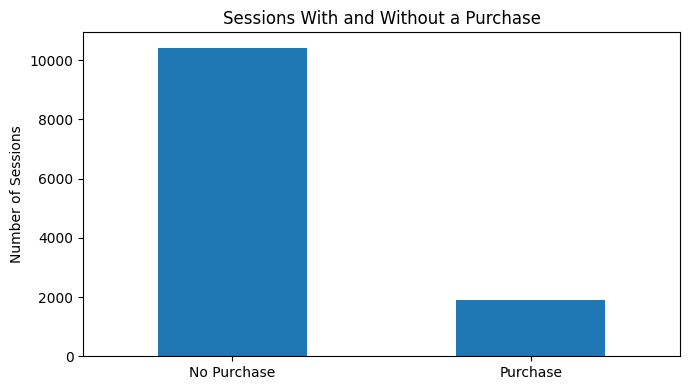

In [7]:
purchase_distribution.plot(kind="bar", figsize=(7, 4))

plt.title("Sessions With and Without a Purchase")
plt.xlabel("")
plt.ylabel("Number of Sessions")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

### First Observation

The overall conversion rate is approximately **15.47%**.

Most sessions do not end in a purchase. The goal is to understand what differentiates converted sessions from non-converted sessions.

## 5. Purchase and Non-Purchase Behaviour

In [8]:
behavior_columns = [
    "administrative",
    "informational",
    "productrelated",
    "administrative_duration",
    "informational_duration",
    "productrelated_duration",
    "bouncerates",
    "exitrates",
    "pagevalues"
]

behavior_comparison = df.groupby("revenue")[behavior_columns].mean().round(2)

behavior_comparison.index = ["No Purchase", "Purchase"]

behavior_comparison

,administrative,informational,productrelated,administrative_duration,informational_duration,productrelated_duration,bouncerates,exitrates,pagevalues
No Purchase,2.12,0.45,28.71,73.74,30.24,1069.99,0.03,0.05,1.98
Purchase,3.39,0.79,48.21,119.48,57.61,1876.21,0.01,0.02,27.26


### Average Number of Pages Viewed

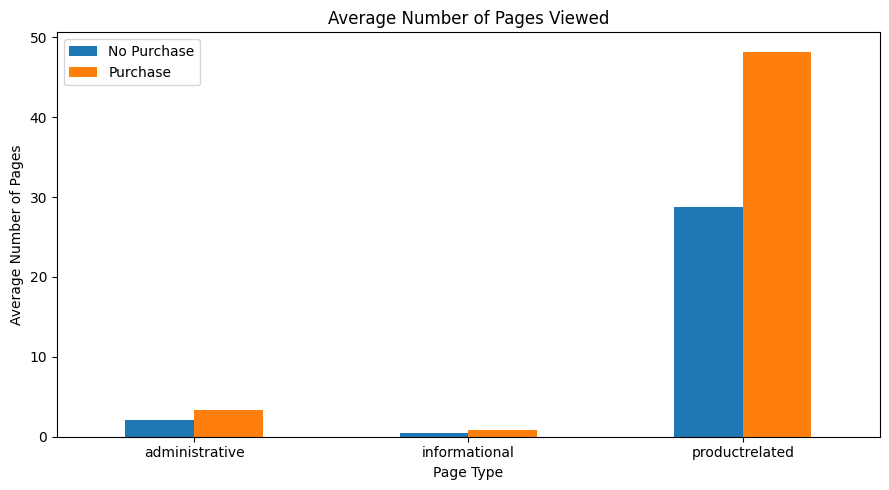

In [9]:
pages_comparison = df.groupby("revenue")[
    ["administrative", "informational", "productrelated"]
].mean().T

pages_comparison.columns = ["No Purchase", "Purchase"]

pages_comparison.plot(kind="bar", figsize=(9, 5))

plt.title("Average Number of Pages Viewed")
plt.xlabel("Page Type")
plt.ylabel("Average Number of Pages")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

### Average Time Spent on Product Pages

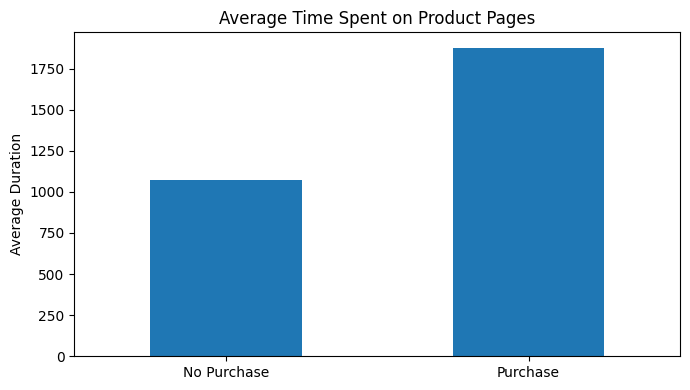

In [10]:
product_duration = df.groupby("revenue")["productrelated_duration"].mean()

product_duration.index = ["No Purchase", "Purchase"]

product_duration.plot(kind="bar", figsize=(7, 4))

plt.title("Average Time Spent on Product Pages")
plt.xlabel("")
plt.ylabel("Average Duration")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

### Average Bounce and Exit Rates

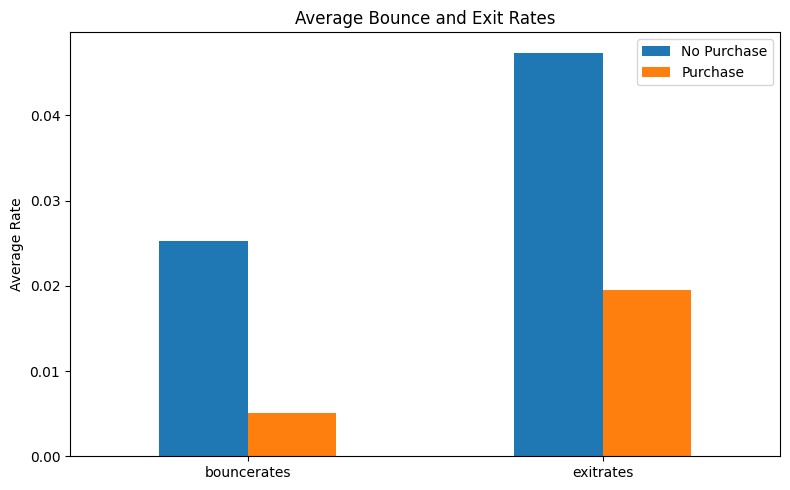

In [11]:
bounce_exit = df.groupby("revenue")[["bouncerates", "exitrates"]].mean().T

bounce_exit.columns = ["No Purchase", "Purchase"]

bounce_exit.plot(kind="bar", figsize=(8, 5))

plt.title("Average Bounce and Exit Rates")
plt.xlabel("")
plt.ylabel("Average Rate")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

### Result

Purchase sessions:

- view an average of **48.21 product pages**, compared with **28.71** for non-purchase sessions;
- spend approximately **1,876** time units on product pages, compared with **1,070**;
- have an average bounce rate of approximately **0.51%**, compared with **2.53%**;
- have an average exit rate of approximately **1.96%**, compared with **4.74%**.

This shows a strong association between product-page engagement and conversion.

## 6. Product Pages Viewed and Conversion

In [12]:
df["product_pages_group"] = pd.cut(
    df["productrelated"],
    bins=[-1, 0, 10, 30, 60, float("inf")],
    labels=["0", "1-10", "11-30", "31-60", "61+"]
)

conversion_by_product_pages = df.groupby(
    "product_pages_group",
    observed=False
)["revenue"].agg(["count", "sum", "mean"])

conversion_by_product_pages.columns = [
    "sessions",
    "purchases",
    "conversion_rate"
]

conversion_by_product_pages["conversion_rate"] = (
    conversion_by_product_pages["conversion_rate"] * 100
).round(2)

conversion_by_product_pages

,sessions,purchases,conversion_rate
product_pages_group,,,
0,38,6,15.79
1-10,4135,281,6.80
11-30,4251,727,17.10
31-60,2229,454,20.37
61+,1677,440,26.24


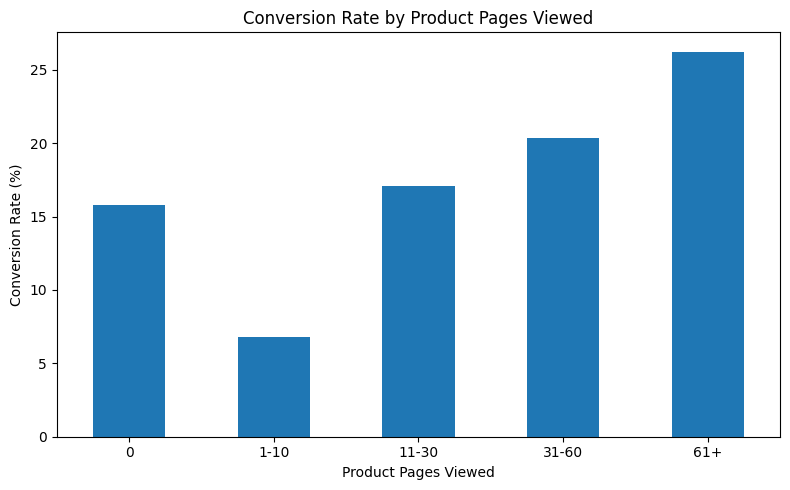

In [13]:
conversion_by_product_pages["conversion_rate"].plot(
    kind="bar",
    figsize=(8, 5)
)

plt.title("Conversion Rate by Product Pages Viewed")
plt.xlabel("Product Pages Viewed")
plt.ylabel("Conversion Rate (%)")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

### Result

Conversion generally increases with the number of product pages viewed:

- **1 to 10 pages: 6.80%**
- **11 to 30 pages: 17.10%**
- **31 to 60 pages: 20.37%**
- **61 pages or more: 26.24%**

This does not prove that viewing more pages causes purchase. It mainly shows that more engaged visitors convert more often.

## 7. Exit Rate and Conversion

In [14]:
df["exit_rate_group"] = pd.cut(
    df["exitrates"],
    bins=[-0.001, 0.02, 0.04, 0.06, 0.10, float("inf")],
    labels=["2% or less", "2-4%", "4-6%", "6-10%", "More than 10%"]
)

conversion_by_exit_rate = df.groupby(
    "exit_rate_group",
    observed=False
)["revenue"].agg(["count", "sum", "mean"])

conversion_by_exit_rate.columns = [
    "sessions",
    "purchases",
    "conversion_rate"
]

conversion_by_exit_rate["conversion_rate"] = (
    conversion_by_exit_rate["conversion_rate"] * 100
).round(2)

conversion_by_exit_rate

,sessions,purchases,conversion_rate
exit_rate_group,,,
2% or less,4842,1201,24.80
2-4%,3709,571,15.39
4-6%,1397,86,6.16
6-10%,1270,44,3.46
More than 10%,1112,6,0.54


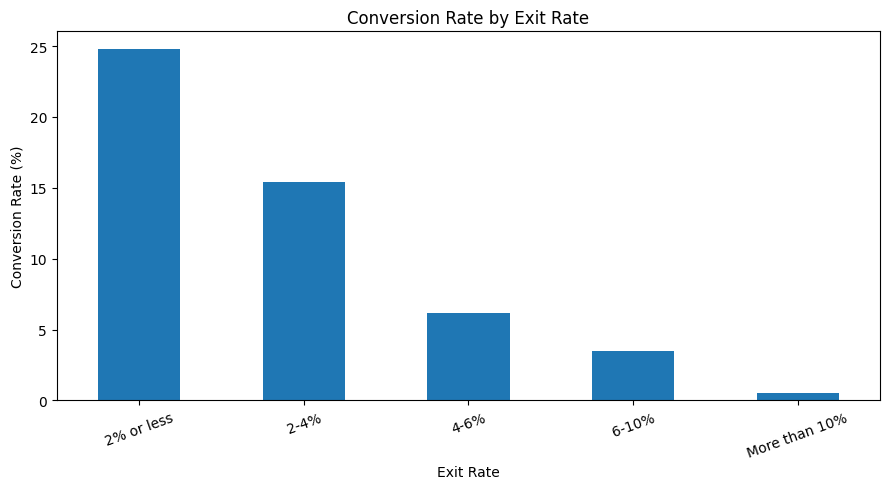

In [15]:
conversion_by_exit_rate["conversion_rate"].plot(
    kind="bar",
    figsize=(9, 5)
)

plt.title("Conversion Rate by Exit Rate")
plt.xlabel("Exit Rate")
plt.ylabel("Conversion Rate (%)")
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

### Result

Conversion decreases sharply as the exit rate increases:

- exit rate of 2% or less: **24.80% conversion**
- exit rate between 4% and 6%: **6.16%**
- exit rate above 10%: only **0.54%**

Reducing early exits is therefore an important improvement opportunity.

## 8. Conversion by Visitor Type

In [16]:
visitor_analysis = df.groupby("visitortype")["revenue"].agg(
    ["count", "sum", "mean"]
)

visitor_analysis.columns = ["sessions", "purchases", "conversion_rate"]
visitor_analysis["conversion_rate"] = (
    visitor_analysis["conversion_rate"] * 100
).round(2)

visitor_analysis = visitor_analysis.sort_values(
    "conversion_rate",
    ascending=False
)

visitor_analysis

,sessions,purchases,conversion_rate
visitortype,,,
New Visitor,1694,422,24.91
Other,85,16,18.82
Returning Visitor,10551,1470,13.93


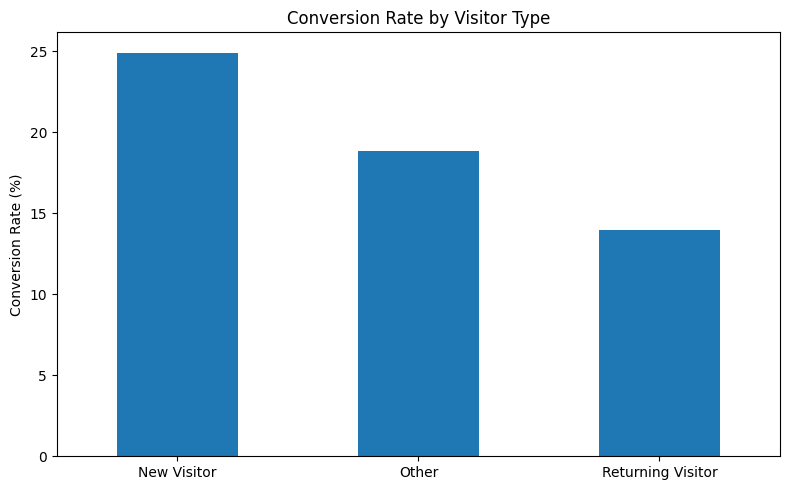

In [17]:
visitor_analysis["conversion_rate"].plot(
    kind="bar",
    figsize=(8, 5)
)

plt.title("Conversion Rate by Visitor Type")
plt.xlabel("")
plt.ylabel("Conversion Rate (%)")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

### Result

- new visitors: **24.91%**
- other visitors: **18.82%**
- returning visitors: **13.93%**

Returning visitors represent most of the traffic, but their conversion rate is lower. Their journey should be analysed in more detail.

## 9. Conversion by Month

In [18]:
monthly_analysis = df.groupby(
    ["month_number", "month"]
)["revenue"].agg(["count", "sum", "mean"]).reset_index()

monthly_analysis.columns = [
    "month_number",
    "month",
    "sessions",
    "purchases",
    "conversion_rate"
]

monthly_analysis["conversion_rate"] = (
    monthly_analysis["conversion_rate"] * 100
).round(2)

monthly_analysis = monthly_analysis.sort_values("month_number")

monthly_analysis

,month_number,month,sessions,purchases,conversion_rate
0,2,Feb,184,3,1.63
1,3,Mar,1907,192,10.07
2,5,May,3364,365,10.85
3,6,Jun,288,29,10.07
4,7,Jul,432,66,15.28
5,8,Aug,433,76,17.55
6,9,Sep,448,86,19.20
7,10,Oct,549,115,20.95
8,11,Nov,2998,760,25.35
9,12,Dec,1727,216,12.51


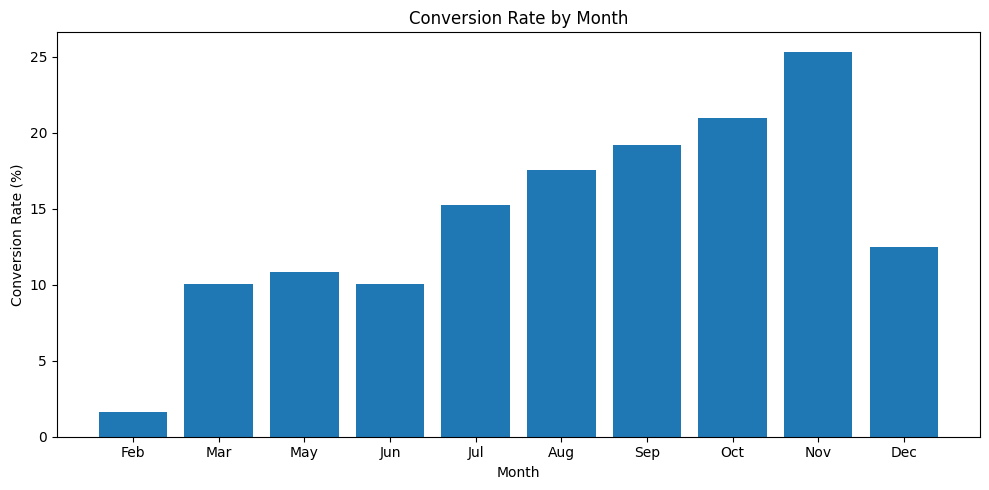

In [19]:
plt.figure(figsize=(10, 5))
plt.bar(
    monthly_analysis["month"],
    monthly_analysis["conversion_rate"]
)

plt.title("Conversion Rate by Month")
plt.xlabel("Month")
plt.ylabel("Conversion Rate (%)")
plt.tight_layout()
plt.show()

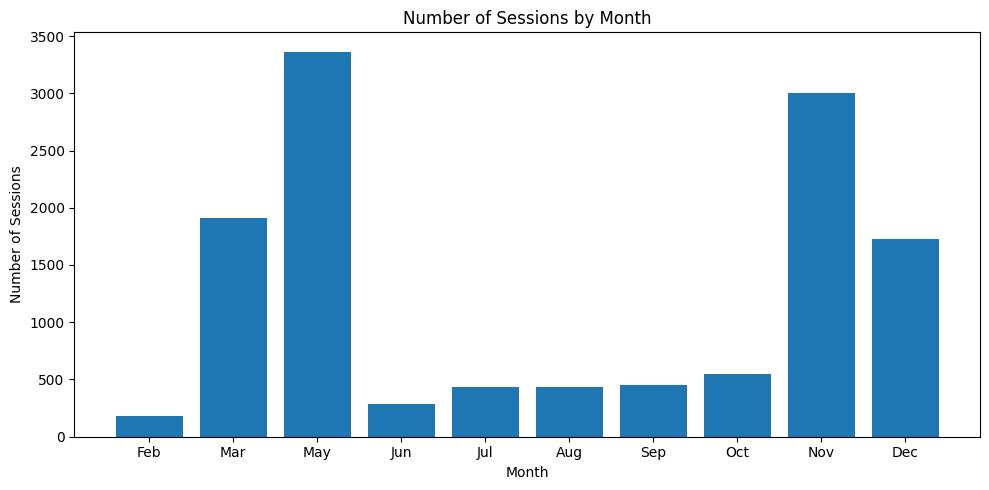

In [20]:
plt.figure(figsize=(10, 5))
plt.bar(
    monthly_analysis["month"],
    monthly_analysis["sessions"]
)

plt.title("Number of Sessions by Month")
plt.xlabel("Month")
plt.ylabel("Number of Sessions")
plt.tight_layout()
plt.show()

### Result

The highest conversion rates occur in:

- **November: 25.35%**
- **October: 20.95%**
- **September: 19.20%**

February has only **1.63%**, but it also contains fewer sessions. November combines high traffic with the strongest conversion rate.

## 10. Weekday or Weekend

In [21]:
weekend_analysis = df.groupby("weekend")["revenue"].agg(
    ["count", "sum", "mean"]
)

weekend_analysis.columns = ["sessions", "purchases", "conversion_rate"]
weekend_analysis.index = ["Weekday", "Weekend"]
weekend_analysis["conversion_rate"] = (
    weekend_analysis["conversion_rate"] * 100
).round(2)

weekend_analysis

,sessions,purchases,conversion_rate
Weekday,9462,1409,14.89
Weekend,2868,499,17.40


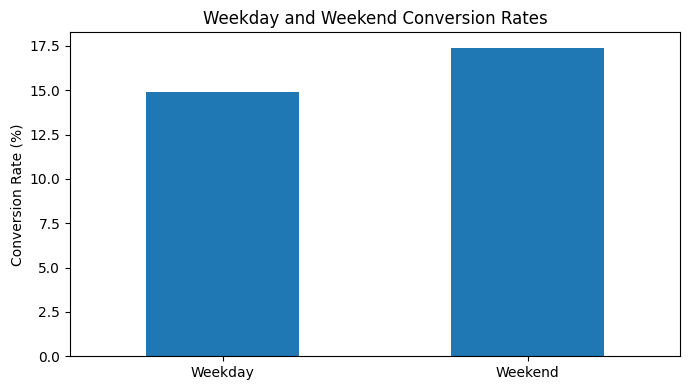

In [22]:
weekend_analysis["conversion_rate"].plot(
    kind="bar",
    figsize=(7, 4)
)

plt.title("Weekday and Weekend Conversion Rates")
plt.xlabel("")
plt.ylabel("Conversion Rate (%)")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

### Result

The conversion rate is slightly higher during the weekend:

- weekday: **14.89%**
- weekend: **17.40%**

The company could test weekend-specific campaigns or promotions.

## 11. Traffic Type Performance

In [23]:
traffic_analysis = df.groupby("traffictype")["revenue"].agg(
    ["count", "sum", "mean"]
).reset_index()

traffic_analysis.columns = [
    "traffictype",
    "sessions",
    "purchases",
    "conversion_rate"
]

traffic_analysis["conversion_rate"] = (
    traffic_analysis["conversion_rate"] * 100
).round(2)

traffic_analysis = traffic_analysis.sort_values(
    "sessions",
    ascending=False
)

traffic_analysis

,traffictype,sessions,purchases,conversion_rate
1,2,3913,847,21.65
0,1,2451,262,10.69
2,3,2052,180,8.77
3,4,1069,165,15.43
12,13,738,43,5.83
9,10,450,90,20.00
5,6,444,53,11.94
7,8,343,95,27.70
4,5,260,56,21.54
10,11,247,47,19.03


Only traffic types with at least 100 sessions are retained to avoid highlighting very small groups.

In [24]:
main_traffic_types = traffic_analysis[
    traffic_analysis["sessions"] >= 100
].copy()

main_traffic_types = main_traffic_types.sort_values(
    "conversion_rate",
    ascending=False
)

main_traffic_types

,traffictype,sessions,purchases,conversion_rate
7,8,343,95,27.70
19,20,198,50,25.25
1,2,3913,847,21.65
4,5,260,56,21.54
9,10,450,90,20.00
10,11,247,47,19.03
3,4,1069,165,15.43
5,6,444,53,11.94
0,1,2451,262,10.69
2,3,2052,180,8.77


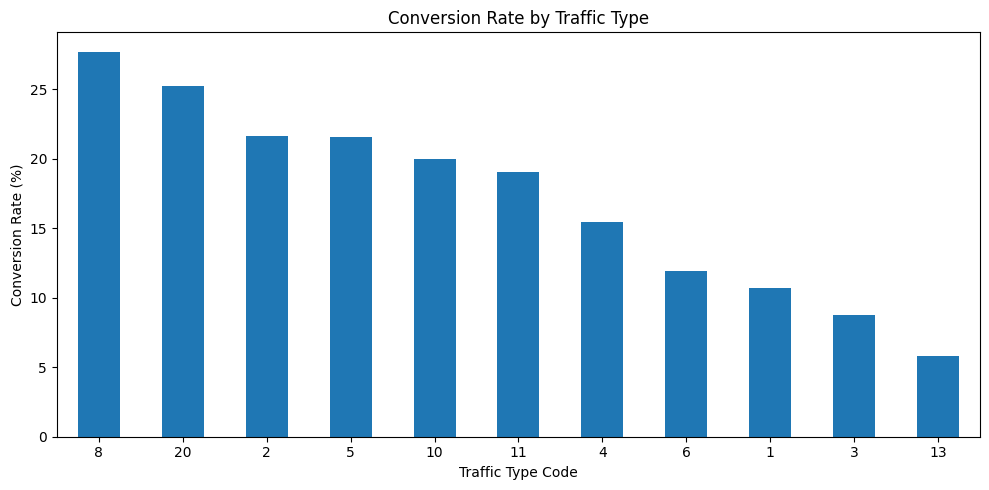

In [25]:
main_traffic_types.plot(
    x="traffictype",
    y="conversion_rate",
    kind="bar",
    figsize=(10, 5),
    legend=False
)

plt.title("Conversion Rate by Traffic Type")
plt.xlabel("Traffic Type Code")
plt.ylabel("Conversion Rate (%)")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

### Result

Among traffic types with at least 100 sessions:

- type **8** reaches approximately **27.70%**
- type **20** reaches approximately **25.25%**
- type **2** reaches approximately **21.65%**
- type **13** reaches approximately **5.83%**

The anonymised codes must be connected to the real acquisition channels before making marketing decisions.

## 12. Variables Most Associated With Purchase

In [26]:
numeric_columns = df.select_dtypes(include="number").columns

correlation_with_purchase = (
    df[numeric_columns]
    .corr()["revenue"]
    .drop("revenue")
    .sort_values(ascending=False)
)

correlation_with_purchase

pagevalues                 0.492569
productrelated             0.158538
productrelated_duration    0.152373
administrative             0.138917
month_number               0.127372
informational              0.095200
administrative_duration    0.093587
informational_duration     0.070345
weekend                    0.029295
browser                    0.023984
traffictype               -0.005113
region                    -0.011595
operatingsystems          -0.014668
specialday                -0.082305
bouncerates               -0.150673
exitrates                 -0.207071
Name: revenue, dtype: float64

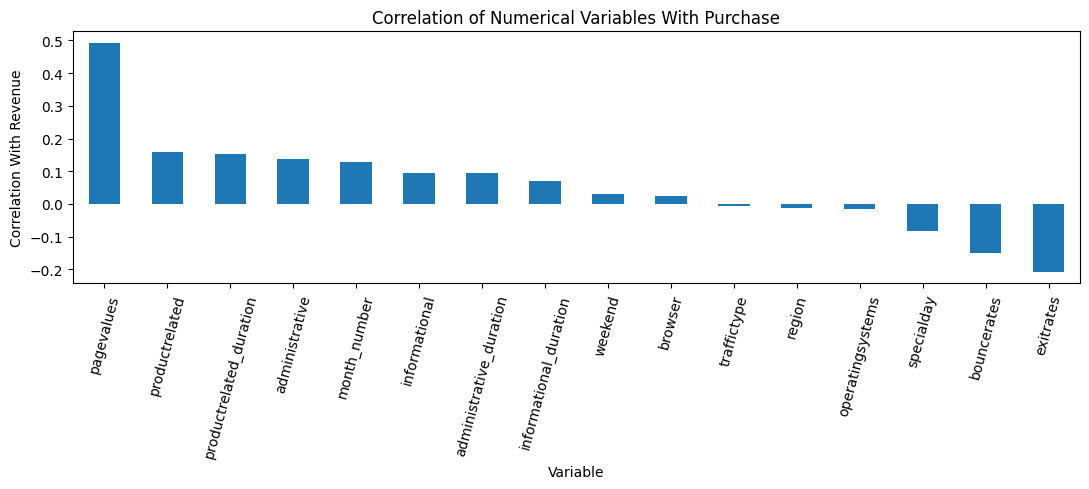

In [27]:
correlation_with_purchase.plot(
    kind="bar",
    figsize=(11, 5)
)

plt.title("Correlation of Numerical Variables With Purchase")
plt.xlabel("Variable")
plt.ylabel("Correlation With Revenue")
plt.xticks(rotation=75)
plt.tight_layout()
plt.show()

### Important Note About `pagevalues`

`pagevalues` is strongly associated with purchase. However, it represents the average value of pages visited before an e-commerce transaction.

It is useful for describing sessions, but it should not be presented as a direct business action. It could also create data leakage in a future predictive model.

# 13. Answer to the Business Question

## Behaviours Associated With Purchase

Visitors who make a purchase:

1. view more product pages;
2. spend more time on product pages;
3. leave the website less quickly;
4. have lower bounce and exit rates;
5. convert more often between September and November;
6. convert slightly better during weekends;
7. come from certain traffic types that perform better.

## Business Recommendations

### Reduce Early Exits

Improve loading speed, navigation, product information, calls to action, and checkout simplicity.

### Encourage Product Exploration

Add recommendations, similar products, better filters, comparison tools, and links to related categories.

### Improve Returning-Visitor Conversion

Use personalised reminders, saved carts, recommendations based on previous visits, and targeted offers.

### Use Strong Seasonal Periods

Increase campaigns between September and November, especially in November.

### Optimise Marketing Investment

Identify the real channels behind the strongest traffic types and compare conversion with acquisition cost.

## Conclusion

The priority is not only to attract more traffic. The company should:

**attract qualified visitors, improve product-page engagement, and reduce exits before purchase.**

# 14. Analysis Limitations

The dataset does not contain:

- a customer identifier;
- order value;
- product-level details;
- real traffic-channel names;
- journeys across multiple sessions;
- marketing costs.

It is therefore not possible to calculate customer retention, customer lifetime value, average order value, marketing ROI, or a complete page-by-page funnel.

The results show associations, not causal relationships.